# Toronto Basement Flooding & Sewer Infrastructure Analysis

This notebook analyses basement flooding incidents by ward, overlaid with:
- Pressurised sewer main counts per ward
- Manhole counts per ward
- E. coli readings at Toronto beaches

Set `use_folium = True` for an interactive Folium map, or `False` for a static Matplotlib map.

## 1. Imports & Configuration

In [1]:
import geopandas as gpd
import pandas as pd
import folium
from folium.features import DivIcon
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
import contextily as ctx
import os

In [2]:
# Set to True for an interactive Folium map, False for a static Matplotlib map
use_folium = False

## 2. Data Loading

In [3]:
wards       = gpd.read_file("data/City_Wards_Data.geojson")
flooding    = pd.read_csv("data/floodings.csv")
ecoli       = gpd.read_file("data/toronto-beaches-water-quality - 4326.geojson")
manholes    = gpd.read_file("data/Sewer Manholes - 4326/Sewer Manholes - 4326.shp")
sewer_mains = gpd.read_file("data/Sewer Pressurized Main - 4326/Sewer Pressurized Main - 4326.shp")

# Match CRS to wards
manholes    = manholes.to_crs(wards.crs)
sewer_mains = sewer_mains.to_crs(wards.crs)

In [4]:
# Inspect column names
print("ecoli columns:   ", ecoli.columns.tolist())
print("flooding columns:", flooding.columns.tolist())
print("wards columns:   ", wards.columns.tolist())

ecoli columns:    ['_id', 'beachId', 'beachName', 'siteName', 'collectionDate', 'eColi', 'comments', 'geometry']
flooding columns: ['Ward', '2019', '2020', '2021', '2022', '2023\r\n(Jan 1 to Jun 30)', 'Total']
wards columns:    ['_id', 'AREA_ID', 'DATE_EFFECTIVE', 'DATE_EXPIRY', 'AREA_ATTR_ID', 'AREA_TYPE_ID', 'PARENT_AREA_ID', 'AREA_TYPE', 'AREA_CLASS_ID', 'AREA_CLASS', 'AREA_SHORT_CODE', 'AREA_LONG_CODE', 'AREA_NAME', 'AREA_DESC', 'FEATURE_CODE', 'FEATURE_CODE_DESC', 'TRANS_ID_CREATE', 'TRANS_ID_EXPIRE', 'OBJECTID', 'geometry']


## 3. Spatial Analysis

Spatially join manholes and sewer mains to wards, then count features per ward.

In [5]:
# Count manholes per ward
manholes_in_wards = gpd.sjoin(manholes, wards, how="left", predicate="within")
manhole_counts = (
    manholes_in_wards
    .groupby("_id")
    .size()
    .reset_index(name="manhole_count")
)
manhole_counts.head()

,_id,manhole_count
0,1.0,6541
1,2.0,7045
2,3.0,5989
3,4.0,5219
4,5.0,5566


In [6]:
# Count pressurised sewer mains per ward
mains_in_wards = gpd.sjoin(sewer_mains, wards, how="left", predicate="within")
mains_counts = (
    mains_in_wards
    .groupby("_id")
    .size()
    .reset_index(name="main_count")
)
mains_counts.head()

,_id,main_count
0,2.0,4
1,4.0,6
2,5.0,3
3,6.0,27
4,7.0,15


## 4. Data Merging

In [7]:
merged = wards.merge(flooding, left_on="_id", right_on="Ward")
merged = merged.merge(mains_counts, on="_id", how="left")
merged = merged.merge(manhole_counts, on="_id", how="left")

merged["manhole_count"] = merged["manhole_count"].fillna(0).astype(int)
merged["main_count"]    = merged["main_count"].fillna(0).astype(int)

merged[["_id", "Total", "main_count", "manhole_count"]].head(10)

,_id,Total,main_count,manhole_count
0,1,351,0,6541
1,2,1117,4,7045
2,3,1327,0,5989
3,4,1151,6,5219
4,5,923,3,5566
5,6,649,27,6968
6,7,189,15,7927
7,8,1070,0,6520
8,9,1308,2,6405
9,10,164,2,6943


## 5. CRS Reprojection for Visualisation

In [8]:
target_crs = 4326 if use_folium else 3857

merged      = merged.to_crs(epsg=target_crs)
manholes    = manholes.to_crs(epsg=target_crs)
sewer_mains = sewer_mains.to_crs(epsg=target_crs)
ecoli       = ecoli.to_crs(epsg=target_crs)

print(f"All layers reprojected to EPSG:{target_crs}")

All layers reprojected to EPSG:3857


## 6. Folium Interactive Map

> This cell runs only when `use_folium = True`.

In [9]:
if use_folium:

    TOLERANCE = 0.0001

    merged_display = merged[["_id", "Total", "main_count", "manhole_count", "geometry"]].copy()
    merged_display["geometry"] = merged_display.geometry.simplify(TOLERANCE)

    sewer_display = sewer_mains[["geometry"]].copy()
    sewer_display["geometry"] = sewer_display.geometry.simplify(TOLERANCE)

    # Map centre
    center = merged_display.geometry.union_all().centroid
    m = folium.Map(
        location=[center.y, center.x],
        zoom_start=11,
        tiles="CartoDB positron"
    )

    # Choropleth — flooding incidents
    folium.Choropleth(
        geo_data=merged_display,
        data=merged_display,
        columns=["_id", "Total"],
        key_on="feature.properties._id",
        fill_color="OrRd",
        fill_opacity=0.7,
        line_opacity=0.4,
        legend_name="Flooding Incidents by Ward",
    ).add_to(m)

    # Sewer mains layer
    folium.GeoJson(
        sewer_display,
        name="Sewer Mains",
        style_function=lambda x: {"color": "blue", "weight": 1, "opacity": 0.4}
    ).add_to(m)

    # Ward labels (sewer main count at centroid)
    centroids = merged_display.to_crs(3857).geometry.centroid
    centroids = gpd.GeoSeries(centroids, crs=3857).to_crs(4326)
    merged_display["centroid"] = centroids

    for _, row in merged_display.iterrows():
        centroid = row.centroid
        label = int(row["main_count"])
        folium.Marker(
            location=[centroid.y, centroid.x],
            icon=DivIcon(
                html=f'<div style="font-size:10pt;font-weight:bold;color:black">{label}</div>'
            )
        ).add_to(m)

    # E. coli sites (readings > threshold)
    threshold = 200
    ecoli_concerning = ecoli[ecoli["eColi"] > threshold]

    for _, row in ecoli_concerning.iterrows():
        geom = row.geometry
        points = list(geom.geoms) if geom.geom_type == "MultiPoint" else ([geom] if geom.geom_type == "Point" else [])
        for point in points:
            folium.CircleMarker(
                location=[point.y, point.x],
                radius=6,
                color="purple",
                fill=True,
                fill_opacity=0.8,
                popup=f"E. coli: {row['eColi']}"
            ).add_to(m)

    m.save("interactive_map.html")
    print("Map saved as interactive_map.html")
    display(m)

## 7. Matplotlib Static Map

> This cell runs only when `use_folium = False`.

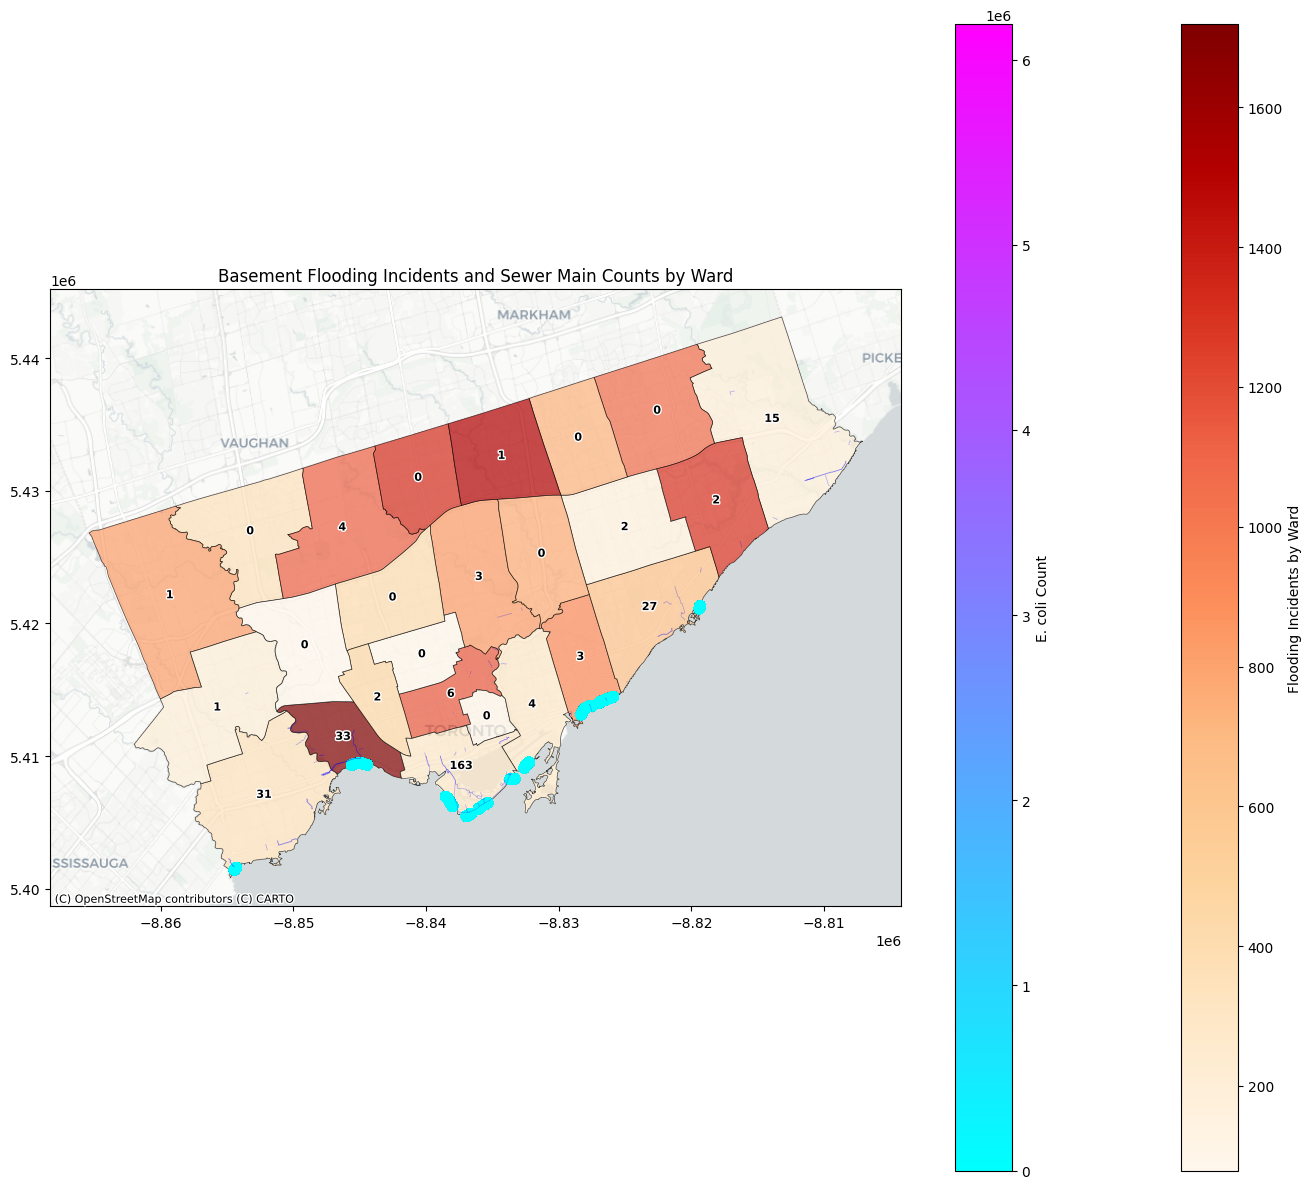

In [10]:
if not use_folium:

    fig, ax = plt.subplots(figsize=(14, 12))

    # Choropleth — flooding incidents
    merged.plot(
        column="Total",
        ax=ax,
        cmap="OrRd",
        legend=True,
        legend_kwds={"label": "Flooding Incidents by Ward"},
        edgecolor="black",
        linewidth=0.5,
        alpha=0.7
    )

    # Sewer mains
    sewer_mains.plot(ax=ax, color="blue", linewidth=0.5, alpha=0.3)

    # Ward labels — sewer main count at centroid
    for _, row in merged.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(
            text=str(row["main_count"]),
            xy=(centroid.x, centroid.y),
            ha="center", va="center",
            fontsize=8, fontweight="bold", color="black",
            path_effects=[path_effects.withStroke(linewidth=2, foreground="white")]
        )

    # E. coli sampling sites
    ecoli.plot(
        ax=ax,
        column="eColi",
        cmap="cool",
        markersize=50,
        alpha=0.8,
        legend=True,
        legend_kwds={"label": "E. coli Count"},
    )

    # Basemap
    os.environ["USER_AGENT"] = "my-geopandas-map-script"
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    ax.set_title("Basement Flooding Incidents and Sewer Main Counts by Ward")
    plt.tight_layout()
    plt.show()